# Titanic Dataset Analysis  
**Author**: Bassam Nazemi  
**Date**: April 2025  
**Purpose**: Exploratory analysis of survival patterns.  

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load datasets

In [2]:
df = pd.read_csv("titanic.csv", index_col=0)
print(df.shape)
df.head()

(891, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Checking the type of columns and handling missing values for each column

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [4]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [5]:
# Percentage of missing values for incomplete columns
print("Percentage of missing values for the Age column:", round(df['Age'].isna().sum() / len(df), 2) * 100, '%')
print("Percentage of missing values for the Cabin column:", round(df['Cabin'].isna().sum() / len(df), 2) * 100, '%')

Percentage of missing values for the Age column: 20.0 %
Percentage of missing values for the Cabin column: 77.0 %


In [6]:
# Delete rows with missing values for the Embarked column --> only 2 rows
df.dropna(subset=['Embarked'], inplace=True)

In [7]:
# Drop Cabin column cause of too many missing values and not deep context
df.drop('Cabin', axis=1, inplace=True)

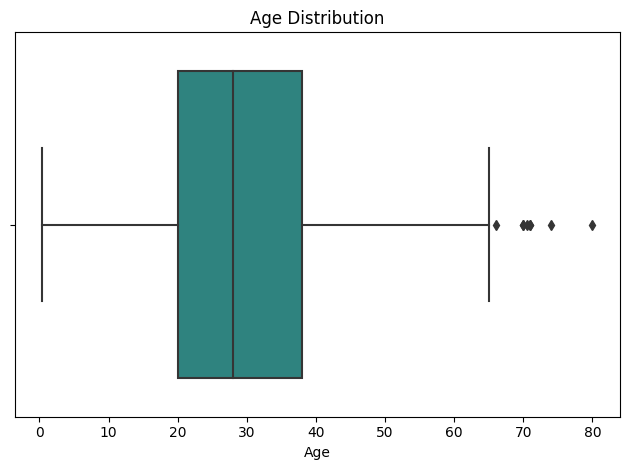

In [8]:
# Check outliers for Age column
sns.boxplot(x=df['Age'], palette="viridis")
plt.title("Age Distribution");
plt.tight_layout()

In [9]:
# Check outliers for Age column
q1_age, q3_age = df['Age'].quantile([0.25, 0.75])
iqr_age = q3_age - q1_age
df[(df['Age'] > q3_age + 1.5 * iqr_age) | (q1_age - 1.5 * iqr_age > df['Age'])]['Age']

PassengerId
34     66.0
97     71.0
117    70.5
494    71.0
631    80.0
673    70.0
746    70.0
852    74.0
Name: Age, dtype: float64

#### <p>After analyzing the Age distribution, I confirmed that all values fall within a biologically plausible range (0 to 80 years). The slight right skew—with fewer older passengers—is expected for passenger demographics and does not indicate data errors. Thus, I retained all age values without modification to preserve data integrity.</p>

In [10]:
# Fill missing values for Age column with median of Age column
df['Age'].fillna(df['Age'].median(), inplace=True)

In [11]:
# All missing values are handled
print(df.isna().sum())
df.head()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [12]:
# Save cleaned dataset
df.to_csv("cleaned_titanic.csv")

### Performing Analyses

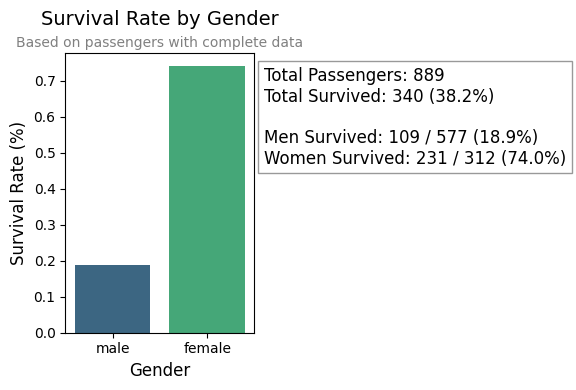

In [13]:
fig1, ax1 = plt.subplots(figsize=(6, 4))
sns.barplot(x=df['Sex'], y=df['Survived'], errorbar=None, palette="viridis", ax=ax1)
ax1.set_title("Survival Rate by Gender", pad=20, fontsize=14)
ax1.text(0.5, 1.02, "Based on passengers with complete data", 
         transform=ax1.transAxes, ha="center", fontsize=10, color="grey")
ax1.set_xlabel("Gender", fontsize=12)
ax1.set_ylabel("Survival Rate (%)", fontsize=12)

# calculate survival stats
total_passengers = len(df)
total_survived = df['Survived'].sum()

men = df[df['Sex'] == "male"]
women = df[df['Sex'] == "female"]

survived_men = men[men["Survived"] == 1]
survived_women = women[women["Survived"] == 1]

stats_text = (
    f"Total Passengers: {total_passengers}\n"
    f"Total Survived: {total_survived} ({total_survived / total_passengers:.1%})\n\n"
    f"Men Survived: {len(survived_men)} / {len(men)} ({len(survived_men) / len(men):.1%})\n"
    f"Women Survived: {len(survived_women)} / {len(women)} ({len(survived_women) / len(women):.1%})"
)

ax1.text(1.05, 0.95, stats_text, transform=ax1.transAxes, 
         fontsize=12, va="top", ha="left", bbox=dict(facecolor="white", alpha=0.8, edgecolor="grey"))
plt.tight_layout();

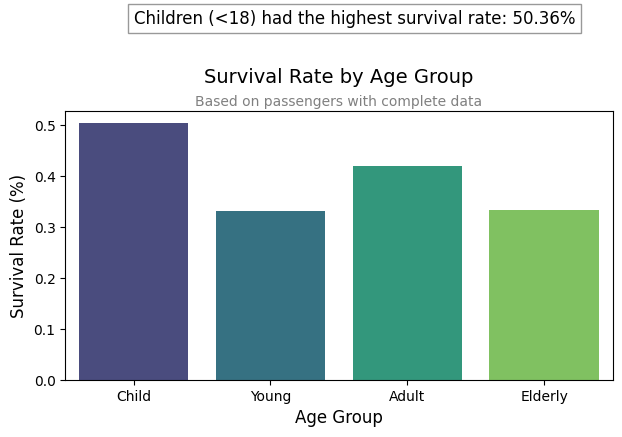

In [14]:
# Split passengers to groups by their ages
bins = [0, 18, 30, 50, 100]
labels = ["Child", "Young", "Adult", "Elderly"]
df['AgeGroup'] = pd.cut(df['Age'], bins, labels=labels)

fig2, ax2 = plt.subplots()

sns.barplot(x=df['AgeGroup'], y=df['Survived'], errorbar=None,palette="viridis", ax=ax2)
ax2.set_title("Survival Rate by Age Group", pad=20, fontsize=14)
ax2.text(0.5, 1.02, "Based on passengers with complete data", 
         transform=ax2.transAxes, ha="center", fontsize=10, color="grey")
ax2.set_xlabel("Age Group", fontsize=12)
ax2.set_ylabel("Survival Rate (%)", fontsize=12)

# calculate survival stats
children_survival_rate = df[df['AgeGroup'] == "Child"]['Survived'].mean()

ax2.text(
    x=0, y=0.7,
    s=f"Children (<18) had the highest survival rate: {children_survival_rate:.2%}",
    fontsize=12, 
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="grey")
)

plt.tight_layout()

In [15]:
# Average age of survivers
print(f"Average age of survived men: {round(survived_men['Age'].mean())}")
print(f"Average age of survived women: {round(survived_women['Age'].mean())}")

# Average age of deceased passengers
print(f"Average age of deceased men: {round(men[~men.index.isin(survived_men.index)]['Age'].mean())}")
print(f"Average age of deceased women: {round(women[~women.index.isin(survived_women.index)]['Age'].mean())}")

Average age of survived men: 27
Average age of survived women: 29
Average age of deceased men: 31
Average age of deceased women: 26


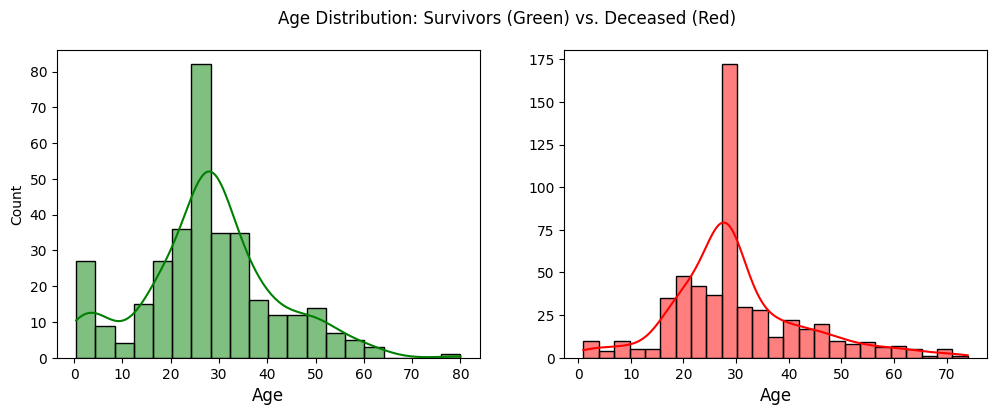

In [16]:
fig3, ax3 = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df[df['Survived'] == 1], x='Age', kde=True, color="green", ax=ax3[0])
sns.histplot(data=df[df['Survived'] == 0], x='Age', kde=True, color="red", ax=ax3[1])

fig3.suptitle("Age Distribution: Survivors (Green) vs. Deceased (Red)")
ax3[0].set_xlabel("Age", fontsize=12)
ax3[1].set_xlabel("Age", fontsize=12)
ax3[0].set_ylabel("Count")
ax3[1].set_ylabel("");

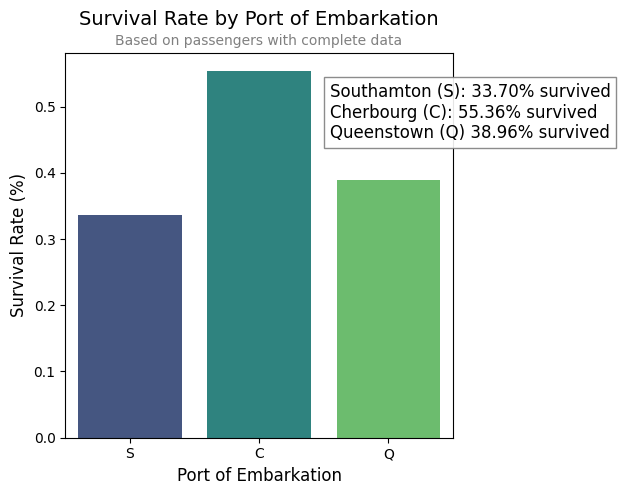

In [17]:
fig4, ax4 = plt.subplots(figsize=(5, 5))

sns.barplot(x=df['Embarked'], y=df['Survived'], errorbar=None,palette="viridis", ax=ax4)
ax4.set_title("Survival Rate by Port of Embarkation", pad=20, fontsize=14)
ax4.text(0.5, 1.02, "Based on passengers with complete data", 
         transform=ax4.transAxes, ha='center', fontsize=10, color="grey")
ax4.set_xlabel('Port of Embarkation', fontsize=12)
ax4.set_ylabel('Survival Rate (%)', fontsize=12)

# calculate survival stats
s_survival_rate = df[df["Embarked"] == "S"]["Survived"].mean()
c_survival_rate = df[df["Embarked"] == "C"]["Survived"].mean()
q_survival_rate = df[df["Embarked"] == "Q"]["Survived"].mean()

stats_text = (
    f"Southamton (S): {s_survival_rate:.2%} survived\n"
    f"Cherbourg (C): {c_survival_rate:.2%} survived\n"
    f"Queenstown (Q) {q_survival_rate:.2%} survived"
)

ax4.text(1.37, 1.25, stats_text, transform=ax1.transAxes, 
         fontsize=12, va="top", ha="left", bbox=dict(facecolor="white", alpha=0.9, edgecolor="grey"));

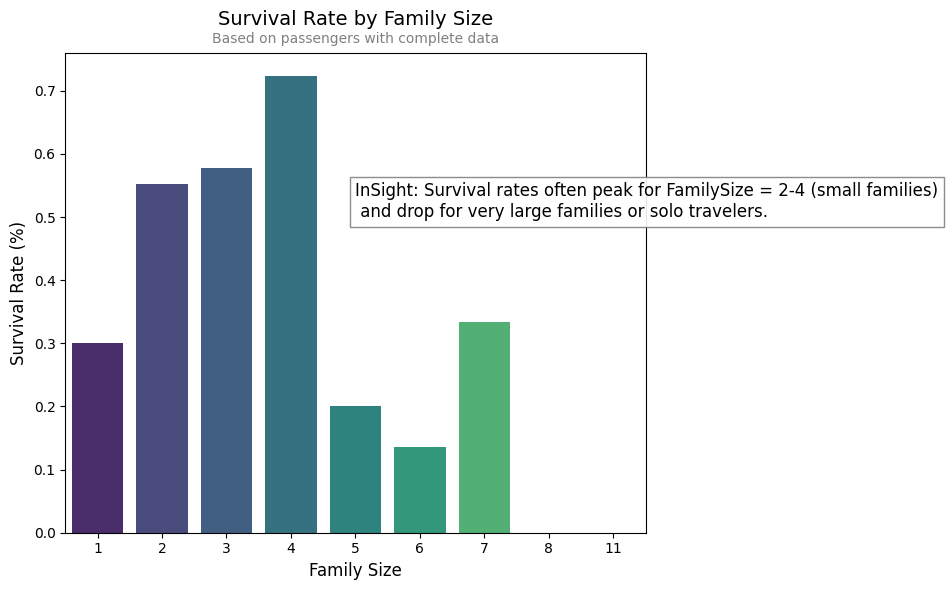

In [18]:
# Calculate family size based on Parch & SibSp
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger

fig5, ax5 = plt.subplots(figsize=(9, 6))


sns.barplot(x=df['FamilySize'], y=df['Survived'], errorbar=None, palette="viridis", ax=ax5)
ax5.set_title("Survival Rate by Family Size", pad=20, fontsize=14)
ax5.text(0.5, 1.02, "Based on passengers with complete data", 
         transform=ax5.transAxes, ha="center", fontsize=10, color="grey")
ax5.set_xlabel("Family Size", fontsize=12)
ax5.set_ylabel("Survival Rate (%)", fontsize=12)

ax5.text(
    x=4, y=0.5,
    s=f"InSight: Survival rates often peak for FamilySize = 2-4 (small families)\n and drop for very large families or solo travelers.",
    fontsize=12, 
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="grey")
)

plt.tight_layout()

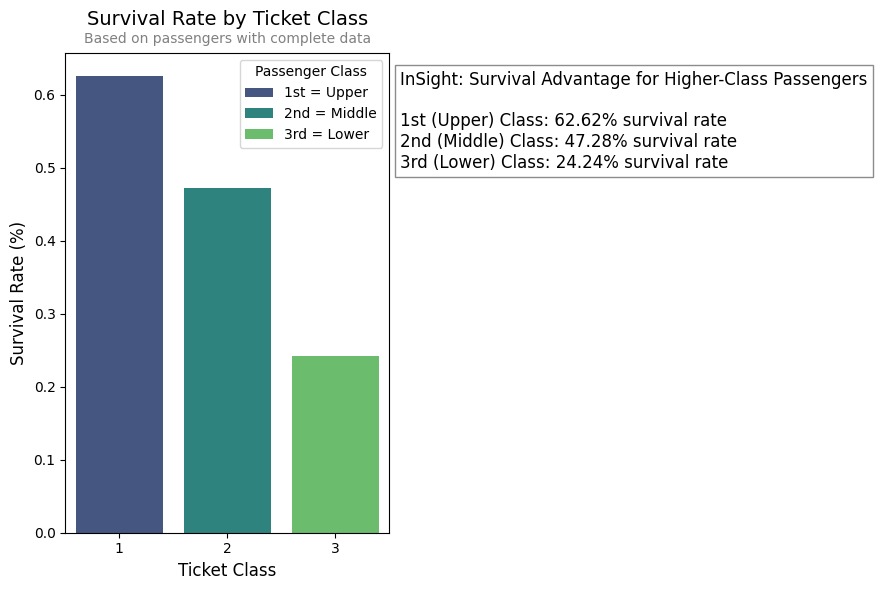

In [19]:
fig6, ax6 = plt.subplots(figsize=(9, 6))
sns.barplot(x=df['Pclass'], y=df['Survived'], errorbar=None, palette="viridis", ax=ax6,)
ax6.set_title("Survival Rate by Ticket Class", pad=20, fontsize=14)
ax6.text(0.5, 1.02, "Based on passengers with complete data", 
         transform=ax6.transAxes, ha="center", fontsize=10, color="gray")
ax6.set_xlabel("Ticket Class", fontsize=12)
ax6.set_ylabel("Survival Rate (%)", fontsize=12)
ax6.legend(
    handles=ax6.patches,  # Bars are patches
    labels=["1st = Upper", "2nd = Middle", "3rd = Lower"],
    title="Passenger Class",
    loc="upper right"
)

# calculate survival rates
first_class_survived = df[df['Pclass'] == 1]['Survived'].mean()
second_class_survived = df[df['Pclass'] == 2]['Survived'].mean()
third_class_survived = df[df['Pclass'] == 3]['Survived'].mean()

text_stats = (
    f"InSight: Survival Advantage for Higher-Class Passengers\n\n"
    f"1st (Upper) Class: {first_class_survived:.2%} survival rate\n"
    f"2nd (Middle) Class: {second_class_survived:.2%} survival rate\n"
    f"3rd (Lower) Class: {third_class_survived:.2%} survival rate"
)

ax6.text(
    x=2.6, y=0.5,
    s=text_stats,
    fontsize=12, 
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="grey")
)

plt.tight_layout()

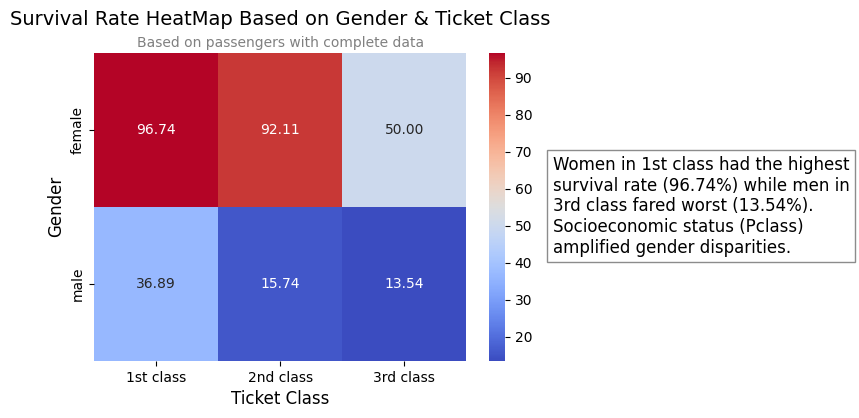

In [20]:
fig7, ax7 = plt.subplots(figsize=(6, 4))
sns.heatmap(df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack() * 100, cmap="coolwarm", annot=True, fmt=".2f", ax=ax7)
ax7.set_title("Survival Rate HeatMap Based on Gender & Ticket Class",pad=20, fontsize=14)
ax7.text(0.5, 1.02, "Based on passengers with complete data", 
         transform=ax7.transAxes, ha="center", fontsize=10, color="gray")
ax7.set_xlabel("Ticket Class", fontsize=12)
ax7.set_ylabel("Gender", fontsize=12)
ax7.set_xticklabels(["1st class", "2nd class", "3rd class"])

ax7.text(
    x=3.7, y=1.3,
    s="Women in 1st class had the highest\nsurvival rate (96.74%) while men in\n3rd class fared worst (13.54%).\nSocioeconomic status (Pclass)\namplified gender disparities.",
    fontsize=12, 
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="grey")
);